# Getting started with pandas

[Pandas](https://github.com/pandas-dev/pandas) is a Python library used for working with data sets.
It has functions for analyzing, cleaning, exploring, and manipulating data.
The name "Pandas" has a reference to both "Panel Data", and "Python Data Analysis" and was created by Wes McKinney in 2008.



In [1]:
import pandas as pd
from babel.messages.jslexer import name_re

### Data Structures
Pandas, in a generic way, contains the following data structures:
* `Series` 1D Array
* `DataFrame` 2D Table
* `Panel` Similar to a dictionary of `DataFrames`

### Creation from a List
We can create series from arrays of Python

In [2]:
s = pd.Series([1,3, 5, 7, 9])
print(f"{s}\n")

0    1
1    3
2    5
3    7
4    9
dtype: int64



### Creation from dictionaries
We can create series from dictionaries and filter which elements we would like to create

In [3]:
dictionary = {"Daniel": 10, "Camila": 8, "Laura": 1, "Raul": 10, "Sebastian": 9, "Sophie": 1_000_000}
print(f"{pd.Series(dictionary)}\n")

print(f"Filtered creation\n{pd.Series(dictionary, index=["Daniel", "Sebastian", "Sophie", "Non Existent Key"])}")


Daniel            10
Camila             8
Laura              1
Raul              10
Sebastian          9
Sophie       1000000
dtype: int64

Filtered creation
Daniel                   10.0
Sebastian                 9.0
Sophie              1000000.0
Non Existent Key          NaN
dtype: float64


### Access to Series objects
We can access a series object by keys (the index are deprecated)

In [4]:
s = pd.Series({ "Miguel": 21, "Sebastian": 20, "Daniel": 17, "Sophia": 21})
print(f"Access by key Sophia is {s["Sophia"]}\n")

# We can also access with the method loc
print(f"Accessing with loc method {s.loc["Sophia"]}\n")

# We can access to an object through its index
print(f"Accessing with iloc method {s.iloc[3]}\n")

#The method iloc allows us slicing
print(f"Accessing with iloc slicing \n{s.iloc[1:4]}\n")

Access by key Sophia is 21

Accessing with loc method 21

Accessing with iloc method 21

Accessing with iloc slicing 
Sebastian    20
Daniel       17
Sophia       21
dtype: int64



### We can also use different numpy functions to Series from pandas


In [5]:
import numpy as np
print(f"Original series {s}\n")
print(f"Sum: {np.sum(s)}\n")

print(f"Multiplication: {np.prod(s)}\n")

print(f"Division: \n{np.divide(s, np.sum(s))}\n")

print(f"Average: {np.average(s)}\n")

print(f"Median: {np.median(s)}\n")

print(f"Standard deviation: {round(np.std(s), 2)}\n")

Original series Miguel       21
Sebastian    20
Daniel       17
Sophia       21
dtype: int64

Sum: 79

Multiplication: 149940

Division: 
Miguel       0.265823
Sebastian    0.253165
Daniel       0.215190
Sophia       0.265823
dtype: float64

Average: 19.75

Median: 20.5

Standard deviation: 1.64



### Matplotlib to show data
We can use Matplotlib to make graphical representation of the data

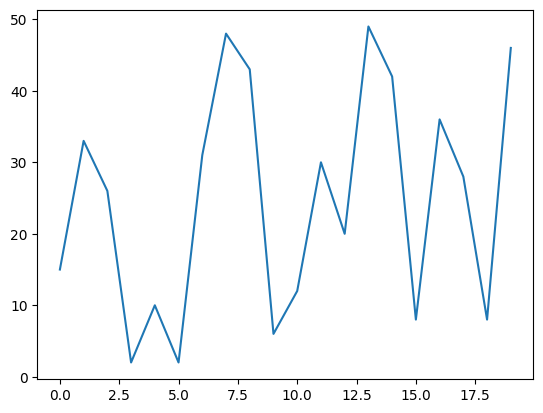

In [6]:
import matplotlib.pyplot as plt
s = pd.Series(np.random.randint(0, 51, size=20), name="Random Graphics")
# Panda method that creates the graphic (internally using matplotlib), sometimes it shows automatically the graphic
s.plot()
# Forces to render the graphic
plt.show()

### Customize graphics with matplotlib
We can change the values of graphics

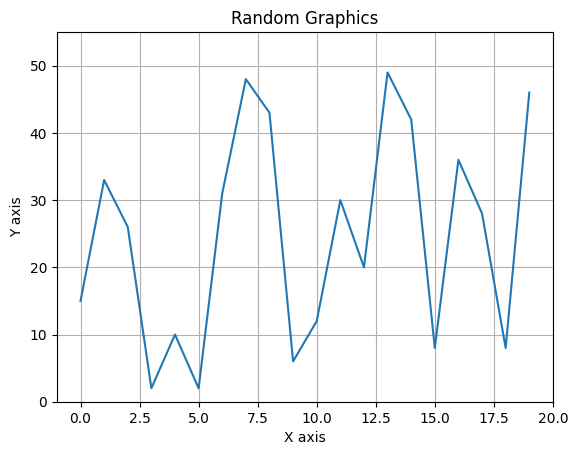

In [7]:
ax = s.plot()
ax.set_title(s.name or "Graphics")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_xlim(-1, 20)
ax.set_ylim(0, 55)
ax.grid(True)

plt.show()

### DataFrames Creation
We can create DataFrames in different ways

In [8]:
people = {
    "weight": pd.Series([89, 32, 45, 87], ["Santiago", "Peter", "Joseph", "Lara"]),
    "height":pd.Series({"Santiago": 179, "Peter": 192, "Joseph": 179, "Lara": 179}),
    "children": pd.Series([2,4], ["Peter", "Lara"])
}
df = pd.DataFrame(people)
df

,weight,height,children
Joseph,45,179,NaN
Lara,87,179,4.0
Peter,32,192,2.0
Santiago,89,179,NaN


We can create this by filtering some information from the dataset

In [9]:
df = pd.DataFrame(people, columns=["weight", "height"], index=["Santiago", "Peter", "Joseph"])
df

,weight,height
Santiago,89,179
Peter,32,192
Joseph,45,179


### Creating a Dataframe from python arrays

In [10]:
values = [[64,74,5],
          [45,65,1],
          [44,13,31]]

df = pd.DataFrame(values, columns=["Weight", "Height", "Age"], index=['Santiago', 'Peter', 'Joseph'] )
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31


### Accessing DataFrames
There are different ways to access data in a DataFrame

In [11]:
# Get the Column
df["Weight"]

Santiago    64
Peter       45
Joseph      44
Name: Weight, dtype: int64

In [16]:
# Get columns with a condition
df[(df["Weight"] > 44) & (df["Age"] > 4)]

,Weight,Height,Age
Santiago,64,74,5


We can access to the rows of a DataFrame

In [29]:
# Return the information of a single record
print(df.loc["Santiago"])

print(f"\n{df.iloc[0]}")

Weight    64
Height    74
Age        5
Name: Santiago, dtype: int64

Weight    64
Height    74
Age        5
Name: Santiago, dtype: int64


We can also use slicing with `iloc`, just as in Series

In [35]:
df.iloc[-2:]

,Weight,Height,Age
Peter,45,65,1
Joseph,44,13,31


### Queries
We can access data by queries like in SQL

In [52]:
# Create some data
new_set = pd.DataFrame([[80, 180, 21], [60, 175, 23], [90, 190, 20]], columns=["Weight", "Height", "Age"], index=['Larry', 'Jack', 'Ryan'])
# Add data
df = pd.concat([df, new_set], ignore_index=False)
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


In [53]:
df# = df.drop(["Larry", "Jack", "Ryan"]) # Delete registers with the same key


,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


Making queries as in SQL is easy

In [56]:
df.query("Weight >= 60 and Age > 20")

,Weight,Height,Age
Larry,80,180,21
Jack,60,175,23


In [57]:
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


### Make a copy
We can make a copy of a DataFrame (independent object)

In [59]:
df_copy = df.copy()
df_copy

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


In [60]:
df_copy = df_copy.drop(["Peter", "Santiago"])
df_copy

,Weight,Height,Age
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


In [61]:
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


### Add new column to a dataset
We can add new columns to datasets

In [62]:
df["Role"] = ["Student", "Teacher", "Student", "Student", "Teacher", "Teacher"]
df

,Weight,Height,Age,Role
Santiago,64,74,5,Student
Peter,45,65,1,Teacher
Joseph,44,13,31,Student
Larry,80,180,21,Student
Jack,60,175,23,Teacher
Ryan,90,190,20,Teacher


In [63]:
# We can also add a column by creating a dataset
df_mod = df.assign(pets=[2,1,2,0,1,0])
df_mod

,Weight,Height,Age,Role,pets
Santiago,64,74,5,Student,2
Peter,45,65,1,Teacher,1
Joseph,44,13,31,Student,2
Larry,80,180,21,Student,0
Jack,60,175,23,Teacher,1
Ryan,90,190,20,Teacher,0


In [65]:
# The original dataset has not changed
df

,Weight,Height,Age,Role
Santiago,64,74,5,Student
Peter,45,65,1,Teacher
Joseph,44,13,31,Student
Larry,80,180,21,Student
Jack,60,175,23,Teacher
Ryan,90,190,20,Teacher


### Delete existent column from dataset
We can delete a column from the dataset too

In [66]:
del df["Role"]
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


In [73]:
# We can also delete an existent column returning a copy of the DataFrame result

df_mod = df.drop(["Height"], axis=1)
df_mod

,Weight,Age
Santiago,64,5
Peter,45,1
Joseph,44,31
Larry,80,21
Jack,60,23
Ryan,90,20


### DataFrame expressions evaluation

In [74]:
df

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


We can execute different operations and create a column with the result in a new set

In [77]:
df.eval("W_H = Weight / Height")

,Weight,Height,Age,W_H
Santiago,64,74,5,0.864865
Peter,45,65,1,0.692308
Joseph,44,13,31,3.384615
Larry,80,180,21,0.444444
Jack,60,175,23,0.342857
Ryan,90,190,20,0.473684


In [79]:
# We can also use variables
min_age = 10
mask = df.eval("Age > @min_age")
df[mask]

,Weight,Height,Age
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


We can apply an external func to the dataset

In [80]:
def pow_two(x):
    return x ** 2
df["Age"].apply(pow_two)

Santiago     25
Peter         1
Joseph      961
Larry       441
Jack        529
Ryan        400
Name: Age, dtype: int64

In [82]:
df # It does not change the original dataset

,Weight,Height,Age
Santiago,64,74,5
Peter,45,65,1
Joseph,44,13,31
Larry,80,180,21
Jack,60,175,23
Ryan,90,190,20


### Save and Load DataFrame
We can save and store DataFrame too

In [85]:
df.to_csv("df_copy.csv")
df.to_html("df_copy.html")
df.to_json("df_copy.json")

We can load the data as well

In [ ]:
df2 = pd.read_csv("df_copy.csv") # , index_col=0 (To parse correctly the index)